In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split

Matplotlib is building the font cache; this may take a moment.


In [2]:
#LOAD DATASET
PATH = "./Dataset/"
CLASS_NAMES = os.listdir(PATH)
print("Classes: ", CLASS_NAMES)

Classes:  ['Broccoli', 'Carrot', 'Cucumber', 'Tomato']


In [3]:
#LOAD IMAGE
rows, cols = 224, 224

#x = image
#y = label (index -> Broccoli = 0, Carrot = 1, Cucumber = 2, Tomato = 3)
x, y = [], []

counter = 0 #utk nentuin index

for class_name in CLASS_NAMES:
    for img_name in os.listdir(PATH + class_name):
        path = f"{PATH}{class_name}/{img_name}"
        label = counter
        image = tf.keras.preprocessing.image.load_img(path, target_size=(rows, cols), color_mode="grayscale")   #soal minta grayscale, klo biasa = RGB
        image = tf.keras.preprocessing.image.img_to_array(image)
        
        x.append(image)
        y.append(label)
    counter += 1
    print(class_name)
    
#RANDOM SHUFFLE DATASET
x = np.array(x)
y = np.array(y)
idx = np.random.permutation(len(x)) #tiap index random dan muncul sekali (cth len(4) -> random antar 0, 1, 2, 3)

#[A, B, C, D]
#idx = [2, 0, 3, 1] -> C, A, D, B (descending)
x, y = x[idx], y[idx]

Broccoli
Carrot
Cucumber
Tomato


In [4]:
#SPLIT DATASET
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

In [5]:
#DATA PREPROCESSING
#1. reshaping -> reshape(jmlh gambar, tinggi gambar, lebar gambar, jmlh channel dr gambar)
#2. convert to float32
#3. divide image pixels by 255
x_train = x_train.reshape(-1, rows, cols, 1).astype('float32')/255.0 #-1 -> numpy hitung otomatis, grayscale channel = 1, rgb = 3
x_val = x_val.reshape(-1, rows, cols, 1).astype('float32')/255.0
x_test = x_test.reshape(-1, rows, cols, 1).astype('float32')/255.0

#4. categorical encoding for target variable (y)
y_train = keras.utils.to_categorical(y_train, num_classes=4) #ada 4 class di dataset
y_val = keras.utils.to_categorical(y_val, num_classes=4) 
y_test = keras.utils.to_categorical(y_test, num_classes=4) 

In [10]:
#DCNN MODEL ARCHITECTURE
model = keras.Sequential([
    
    #INPUT LAYER -> define dimensions & channel (ini 1 krn grayscale)
    keras.layers.Input(shape=(rows, cols, 1)),
    
    #HIDDEN LAYER -> brp dimensi (bs 64, 32, 6), kernel, activation
    keras.layers.Conv2D(6, (5, 5), activation = 'relu'),    #conv2D = yellow
    keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2), #strides = filter geser brp pixel tiap iterasi (pooling = red)
    keras.layers.Conv2D(16, (5, 5), activation = 'relu'),
    keras.layers.Conv2D(16, (5, 5), activation = 'relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    keras.layers.Flatten(),
    
    #OUTPUT LAYER -> 2 dense layers (relu, softmax)
    keras.layers.Dense(120, activation = 'relu'),
    keras.layers.Dense(4, activation = 'softmax')
    
])

#note: square di gambar makin kecil, dimensinya makin besar (?)

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 220, 220, 6)       156       
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 110, 110, 6)      0         
 2D)                                                             
                                                                 
 conv2d_6 (Conv2D)           (None, 106, 106, 16)      2416      
                                                                 
 conv2d_7 (Conv2D)           (None, 102, 102, 16)      6416      
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 51, 51, 16)       0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 41616)             0

In [12]:
#MODEL TRAINING
#1. use adam optimizer
#2. select loss function (BCE = 2 class, CE for > 2 class)
#3. monitor performance (soal minta accuracy as metric)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=10)

Epoch 1/10
50/50 [==============================] - 31s 610ms/step - loss: 1.1536 - accuracy: 0.4625 - val_loss: 0.8518 - val_accuracy: 0.7100
Epoch 2/10
50/50 [==============================] - 31s 624ms/step - loss: 0.6157 - accuracy: 0.7656 - val_loss: 0.6294 - val_accuracy: 0.7950
Epoch 3/10
50/50 [==============================] - 31s 619ms/step - loss: 0.4391 - accuracy: 0.8438 - val_loss: 0.5042 - val_accuracy: 0.8150
Epoch 4/10
50/50 [==============================] - 31s 627ms/step - loss: 0.3184 - accuracy: 0.8881 - val_loss: 0.3428 - val_accuracy: 0.8800
Epoch 5/10
50/50 [==============================] - 29s 586ms/step - loss: 0.1591 - accuracy: 0.9500 - val_loss: 0.3476 - val_accuracy: 0.8650
Epoch 6/10
50/50 [==============================] - 29s 586ms/step - loss: 0.1355 - accuracy: 0.9600 - val_loss: 0.3598 - val_accuracy: 0.8700
Epoch 7/10
50/50 [==============================] - 31s 613ms/step - loss: 0.0663 - accuracy: 0.9844 - val_loss: 0.3467 - val_accuracy: 0.8800

In [13]:
#PREDICT DATA
prediction = model.predict(x_test)                  #ksh probability masuk ke tiap kelas brp %
predicted_class = np.argmax(prediction, axis = 1)   #ambil nilai max dr probability masuk kelas yg mn

#PRINT LOSS & ACCURACY
score = model.evaluate(x_test, y_test)
print(f"Test accuracy: {score[1]}")
print(f"Test accuracy: {score[0]}")

7/7 [==============================] - 1s 70ms/step - loss: 0.5957 - accuracy: 0.8650
Test accuracy: 0.8650000095367432
Test accuracy: 0.5957377552986145


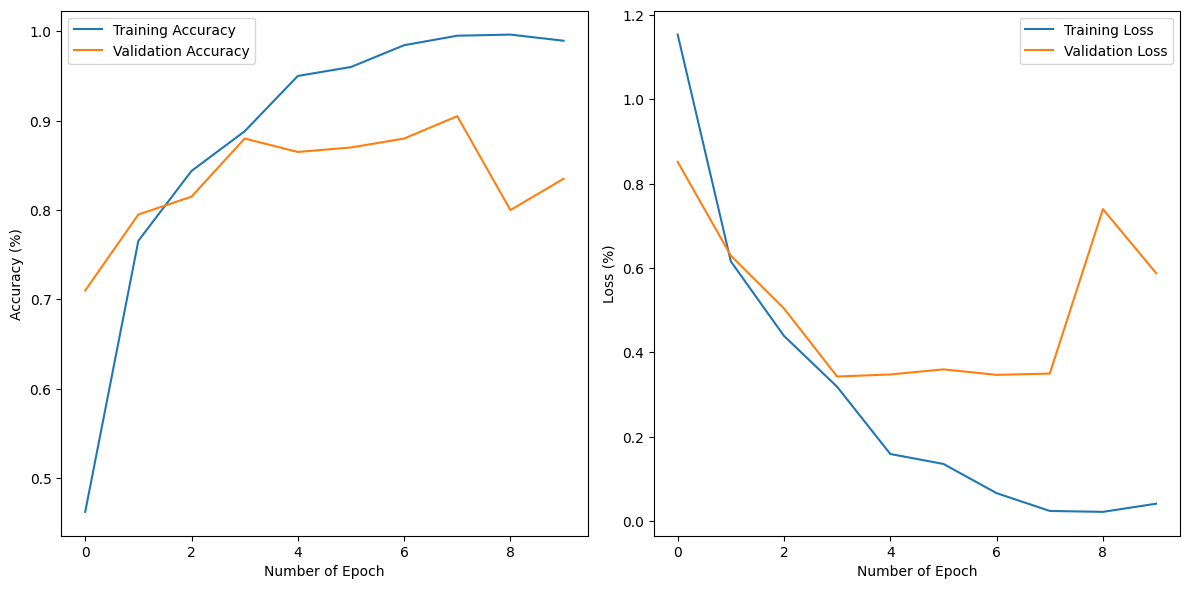

In [14]:
#PLOT EVALUATION METRICS
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Number of Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Number of Epoch')
plt.ylabel('Loss (%)')
plt.legend()

plt.tight_layout()
plt.show()